# 06 Multivariate Mean Reversion

**Book:** *Fixed Income Relative Value Analysis (2nd ed.)*  
**Focus:** Chapter 4 scaffold linking the Chapter 2 OU workflow to a multivariate mean-reversion setup using available Treasury tenors.


## Goals

1. Load a Treasury curve state vector from local data.
2. Build candidate stationary structures using curve spreads and cointegration logic.
3. Scaffold Johansen cointegration and VECM estimation.
4. Translate the fitted system into spread forecasts and trade placeholders.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from quant_data.api import get_data

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

START = "2024-02-26"
END = "2026-02-27"
BOOK_PDF = Path(r"""/Users/zelin/Desktop/阅读学习/Fixed Income Relative Value Analysis + Website A Practitioner’s Guide to the Theory, Tools, and Trades 2nd.pdf""")

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Book PDF exists:", BOOK_PDF.exists())
print("Repo root:", REPO_ROOT)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Book PDF exists: True
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy


In [2]:
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"


def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
treasury_series = ["DGS1", "DGS2", "DGS3", "DGS5", "DGS7", "DGS10", "DGS20", "DGS30"]
curve = load_fred_series(treasury_series).dropna().sort_index()

state = curve[["DGS2", "DGS5", "DGS10", "DGS30"]].copy()
state.columns = ["2Y", "5Y", "10Y", "30Y"]

state["2s5s10s_bfly"] = 2 * state["5Y"] - state["2Y"] - state["10Y"]
state["5s10s30s_bfly"] = 2 * state["10Y"] - state["5Y"] - state["30Y"]

print('curve shape', curve.shape)
print('state shape', state.shape)
state.tail()


curve shape (498, 8)
state shape (498, 6)


              2Y    5Y   10Y   30Y  2s5s10s_bfly  5s10s30s_bfly
date                                                           
2026-02-18  3.47  3.66  4.09  4.71         -0.24          -0.19
2026-02-19  3.47  3.65  4.08  4.70         -0.25          -0.19
2026-02-20  3.48  3.65  4.08  4.72         -0.26          -0.21
2026-02-23  3.43  3.59  4.03  4.70         -0.28          -0.23
2026-02-25  3.45  3.61  4.05  4.70         -0.28          -0.21

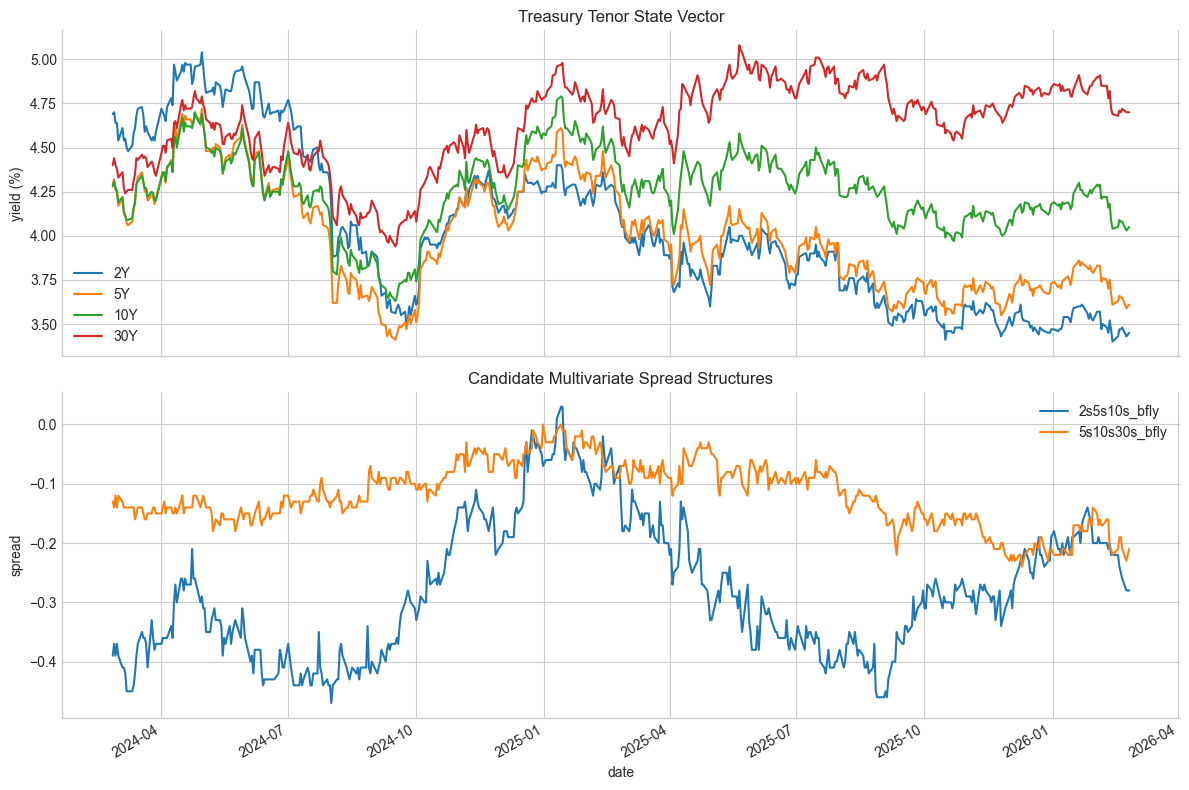

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
state[["2Y", "5Y", "10Y", "30Y"]].plot(ax=axes[0], title="Treasury Tenor State Vector")
axes[0].set_ylabel("yield (%)")

state[["2s5s10s_bfly", "5s10s30s_bfly"]].plot(ax=axes[1], title="Candidate Multivariate Spread Structures")
axes[1].set_ylabel("spread")
plt.tight_layout()
plt.show()


## Real Johansen cointegration and VECM estimation

This version uses the available Treasury tenors directly and estimates:

- Johansen trace statistics
- the first cointegrating vector
- a VECM when the trace test indicates rank `>= 1`
- the resulting multivariate error-correction spread and z-score


In [5]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

vecm_input = state[["2Y", "5Y", "10Y"]].dropna()
johansen = coint_johansen(vecm_input, det_order=0, k_ar_diff=1)

johansen_summary = pd.DataFrame(
    {
        "trace_stat": johansen.lr1,
        "crit_90": johansen.cvt[:, 0],
        "crit_95": johansen.cvt[:, 1],
        "crit_99": johansen.cvt[:, 2],
    },
    index=[f"r <= {i}" for i in range(len(johansen.lr1))],
)

estimated_rank = int((johansen.lr1 > johansen.cvt[:, 1]).sum())
coint_rank = max(1, min(estimated_rank, len(vecm_input.columns) - 1))
beta = pd.Series(johansen.evec[:, 0], index=vecm_input.columns, name='cointegrating_vector')

print('estimated rank (95% trace test):', estimated_rank)
print('using coint_rank for VECM:', coint_rank)
johansen_summary


estimated rank (95% trace test): 0
using coint_rank for VECM: 1


        trace_stat  crit_90  crit_95  crit_99
r <= 0   21.291124  27.0669  29.7961  35.4628
r <= 1    7.742811  13.4294  15.4943  19.9349
r <= 2    1.556721   2.7055   3.8415   6.6349

In [6]:
vecm_model = VECM(vecm_input, k_ar_diff=1, coint_rank=coint_rank, deterministic='co')
vecm_res = vecm_model.fit()

alpha = pd.DataFrame(vecm_res.alpha, index=vecm_input.columns, columns=[f'ec{i+1}' for i in range(vecm_res.alpha.shape[1])])
beta_matrix = pd.DataFrame(vecm_res.beta, index=vecm_input.columns, columns=[f'beta{i+1}' for i in range(vecm_res.beta.shape[1])])
alpha, beta_matrix


/Users/zelin/opt/anaconda3/envs/ibkr-analytics/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(          ec1
2Y  -0.002272
5Y  -0.004055
10Y -0.003902,          beta1
2Y    1.000000
5Y   -5.333471
10Y  12.439625)

In [7]:
cointegrated_spread = (vecm_input * beta_matrix.iloc[:, 0]).sum(axis=1).rename('cointegrated_spread')
spread_z = ((cointegrated_spread - cointegrated_spread.rolling(60).mean()) / cointegrated_spread.rolling(60).std()).rename('zscore')
d_spread = cointegrated_spread.diff().rename('daily_change')
spread_panel = pd.concat([cointegrated_spread, spread_z, d_spread], axis=1)
spread_panel.tail(10)


            cointegrated_spread    zscore  daily_change
date                                                   
2026-02-10            35.464997  0.014401     -0.509704
2026-02-11            35.517116  0.094477      0.052119
2026-02-12            34.774227 -1.286389     -0.742889
2026-02-13            34.402254 -1.904440     -0.371973
2026-02-17            34.449981 -1.755691      0.047727
2026-02-18            34.827562 -1.065927      0.377581
2026-02-19            34.756500 -1.180115     -0.071062
2026-02-20            34.766500 -1.166771      0.010000
2026-02-23            34.414527 -1.779795     -0.351973
2026-02-25            34.576650 -1.516193      0.162123

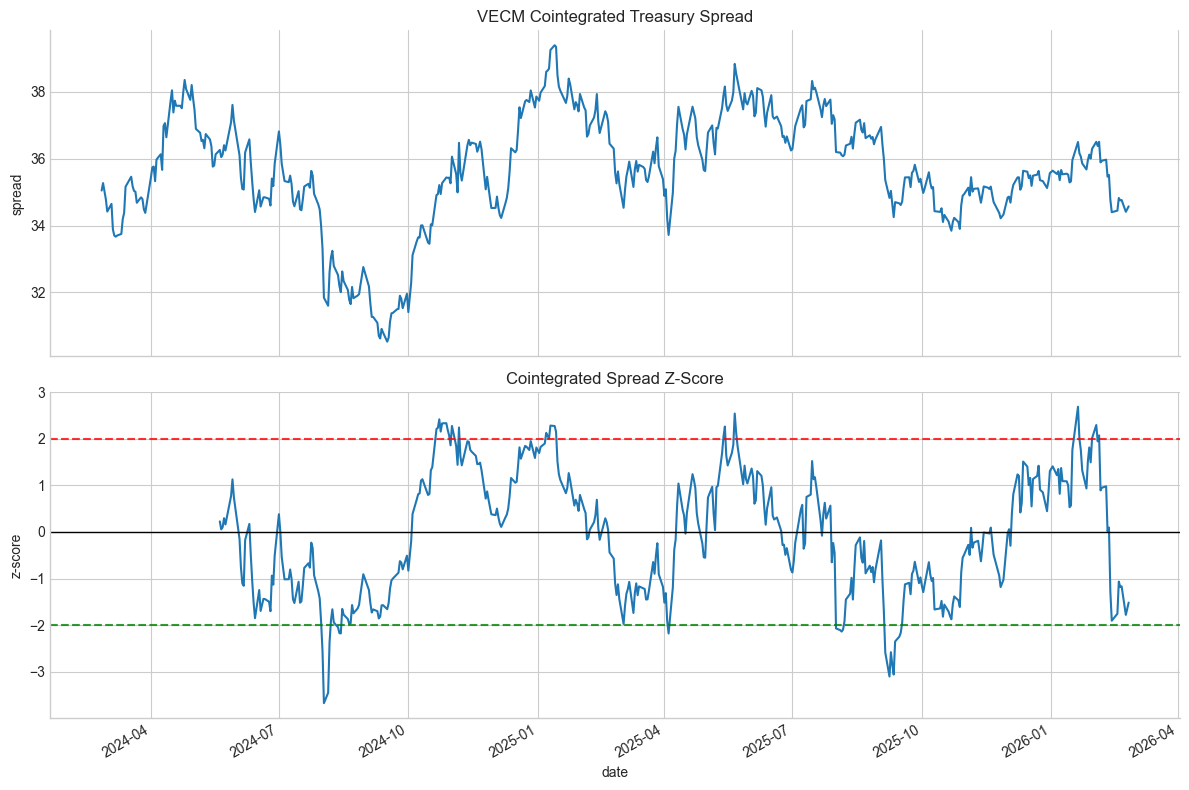

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
spread_panel['cointegrated_spread'].plot(ax=axes[0], title='VECM Cointegrated Treasury Spread')
axes[0].set_ylabel('spread')

spread_panel['zscore'].plot(ax=axes[1], title='Cointegrated Spread Z-Score')
axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.8)
axes[1].axhline(-2.0, color='green', linestyle='--', alpha=0.8)
axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()


## Trade interpretation scaffold

The VECM supplies two useful objects:

- **beta**: the equilibrium relationship / spread definition
- **alpha**: which tenors adjust when the spread is out of equilibrium

This is the multivariate bridge from Chapter 2's scalar OU logic toward system-level trade design.


In [9]:
latest = spread_panel.dropna().iloc[-1]
trade_signal = -1 if latest['zscore'] > 1.5 else (1 if latest['zscore'] < -1.5 else 0)
summary = {
    'latest_date': str(spread_panel.dropna().index[-1].date()),
    'latest_spread': float(latest['cointegrated_spread']),
    'latest_zscore': float(latest['zscore']),
    'signal': int(trade_signal),
}
summary


{'latest_date': '2026-02-25', 'latest_spread': 34.5766504148864, 'latest_zscore': -1.5161929802169432, 'signal': 1}

In [10]:
forecast = vecm_res.predict(steps=10)
forecast_df = pd.DataFrame(forecast, columns=vecm_input.columns)
forecast_df.index = pd.RangeIndex(1, len(forecast_df) + 1, name='step_ahead')
forecast_df


                  2Y        5Y       10Y
step_ahead                              
1           3.449623  3.614441  4.055025
2           3.449652  3.617172  4.059001
3           3.449571  3.619979  4.062630
4           3.449345  3.622556  4.066168
5           3.449074  3.625032  4.069565
6           3.448723  3.627380  4.072843
7           3.448308  3.629612  4.076002
8           3.447826  3.631729  4.079046
9           3.447280  3.633736  4.081978
10          3.446673  3.635636  4.084803

In [11]:
# TODO: compare this multivariate spread forecast to the scalar OU forecast from 01_mean_reversion.ipynb.
# TODO: test alternative state vectors, e.g. [2Y, 5Y, 10Y, 30Y] or PCA residual inputs.
# TODO: evaluate forecast quality and half-life proxies across rolling windows.
